# Llava Model 7b parameters to guess animals

1. Import and install Libraries

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes pillow
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import pipeline, BitsAndBytesConfig
from huggingface_hub import login
from google.colab import userdata

# --- Secure Login ---
print("Logging into Hugging Face...")
hf_key = userdata.get('HF_TOKEN')
login(hf_key)
# --------------------

print("Downloading and Loading LLaVA-1.5 7B...")
print("This requires significant VRAM and may take a few minutes.")

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

vlm_pipeline = pipeline(
    "image-text-to-text",
    model="llava-hf/llava-1.5-7b-hf",
    model_kwargs={"quantization_config": quantization_config},
)
print("Model successfully loaded into GPU!")

Logging into Hugging Face...
This requires significant VRAM and may take a few minutes.


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

Model successfully loaded into GPU!


2. Defning the output

In [ ]:
def identify_animal_blind(image_path):
    image = Image.open(image_path).convert('RGB')

    prompt = '''USER: <image>
Identify the animal shown. Respond ONLY with a valid JSON object: {"animal": "Exact Common Name"}.

CRITICAL RULES:
1. NEVER guess based on a single feature (e.g., bill ≠ duck, gills ≠ frog). Consider full anatomy: fur/feathers/scales? limbs? habitat clues? behavior?
2. Be taxonomically precise: Use species-level common name if possible (e.g., "Red Fox", not "Fox"; "Bald Eagle", not "Eagle").
3. If uncertain between similar species, choose the most visually consistent one — but never default to overly broad terms like "Bird", "Mammal", or "Reptile".
4. Avoid anthropomorphic or vague labels: No "cute creature", "water thing", etc.

EXAMPLES OF GOOD OUTPUT:
{"animal": "Platypus"}
{"animal": "Axolotl"}
{"animal": "Komodo Dragon"}
{"animal": "Snow Leopard"}
{"animal": "Clownfish"}

ASSISTANT:'''

    print("Running deep vision-language analysis...")

    outputs = vlm_pipeline(image, text=prompt, max_new_tokens=50, max_length=None)

    raw_text = outputs[0]['generated_text']
    ai_answer = raw_text.split("ASSISTANT:")[-1].strip()

    plt.imshow(image)
    plt.title(f"AI Identification:\n{ai_answer}", wrap=True)
    plt.axis('off')
    plt.show()

3. Calling The "Guess" Function

[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running deep vision-language analysis...


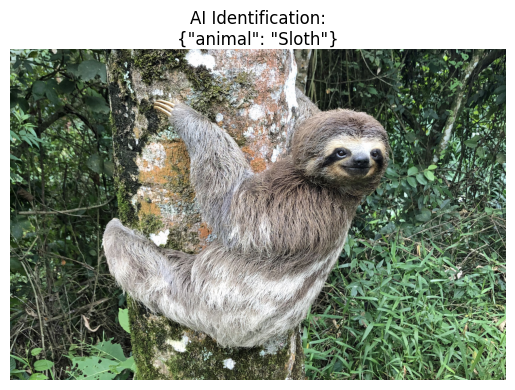

In [ ]:
random_photo = "guess5.png"

identify_animal_blind(random_photo)